# Time-dependent boundary conditions


<!-- Dirichlet, Neumann, Robin and periodic conditions are specified by `BoundaryConditions`. The boundary condition's value of type `Function`, `Constant` or `Expr` can be updated in the time-stepping loop to implement a time-dependent bundary condition.  --> -->

See advection-diffusion-reaction demo for definition of initial boundary value problem.

In [ ]:
import numpy as np

from lucifex.mesh import interval_mesh
from lucifex.fdm import (
    BE, finite_difference_order,
    FiniteDifference, FunctionSeries, ConstantSeries,
)
from lucifex.sim import run, Simulation
from lucifex.fem import Constant
from lucifex.solver import ibvp, evaluation, BoundaryConditions
from lucifex.plt import plot_line, create_animation, save_figure, display_animation
from lucifex.pde.diffusion import diffusion_reaction


def sine_wave(t, eps, omega):
    return eps * np.sin(omega * float(t))


def create_simulation(
    Lx: float,
    Nx: int,
    dt: float,
    eps: float,
    omega: float,
    bc_type: str,
    D_diff: FiniteDifference,
    D_reac: FiniteDifference,
) -> Simulation:
    order = finite_difference_order(D_diff.order, D_reac.order)
    store = 1
    mesh = interval_mesh(Lx, Nx)

    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')  

    uB = ConstantSeries(mesh, order=order, store=store, ics=sine_wave(0.0, eps, omega))
    if bc_type == 'dirichlet':
        uB.name = 'uD'
        bcs = BoundaryConditions(
            ('dirichlet', lambda x: x[0], uB[1]),
            ('dirichlet', lambda x: x[0] - Lx, 0.0),
        )
    elif bc_type == 'neumann':
        uB.name = 'uN'
        bcs = BoundaryConditions(
            ('neumann', lambda x: x[0], -uB[1]),
            ('dirichlet', lambda x: x[0] - Lx, 0.0),
        )
    else:
        raise ValueError

    uB_solver = evaluation(
        uB, 
        sine_wave, 
        future=True,
    )(t[0] + dt, eps, omega)

    u = FunctionSeries((mesh, 'P', 1), 'u', order, store, ics=0.0)
    r = 1 - u
    u_solver = ibvp(diffusion_reaction, bcs=bcs)(u, dt, 1, D_diff, r, D_reac)

    return Simulation([uB_solver, u_solver], t, dt)

## Time-dependent Neumann boundary condition

$$
\mathbb{S}
\begin{cases}
\Omega = [0, L_x] \\
u_{\text{N}}(x=0, t)=\epsilon\sin(\omega t) \\
u_{\text{D}}(x=L_x)=0 
\end{cases}
$$

In [ ]:
Lx = 1.0
Nx = 100
dt = 0.01
eps = 0.1
omega = 20
simulation = create_simulation(Lx, Nx, dt, eps, omega, 'neumann', BE, BE)
n_stop = 50
run(simulation, n_stop)

u = simulation['u']

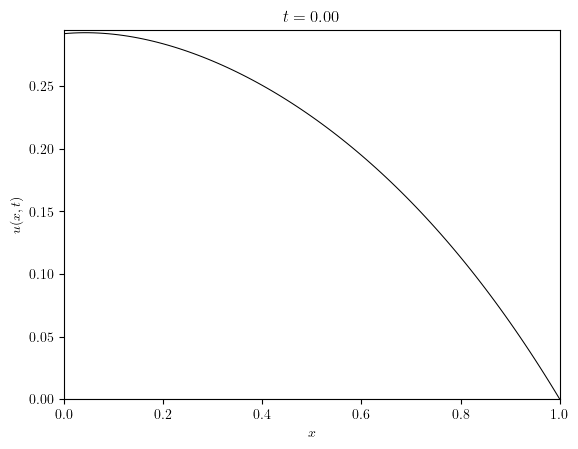

In [ ]:
u_min = np.min([np.min(dofs) for dofs in u.dofs_series])
u_max = np.max([np.max(dofs) for dofs in u.dofs_series])

title_series = [f'$t={t:.2f}$' for t in u.time_series]
anim = create_animation(
    plot_line,
    y_lims=(u_min, u_max),
    x_label='$x$', 
    y_label='$u(x,t)$'
)(u.series, title=title_series)
anim_path = save_figure('neumann_u(t)', return_path=True)(anim)

display_animation(anim_path)